Aviation Passenger Satisfaction Analysis — Enhanced Edition
=============================================================
Business Objective:
    Identify the primary drivers of passenger satisfaction using exploratory
    data analysis, statistical testing, and ensemble machine learning. Results
    are designed to give airline management a clear, data-backed roadmap for
    capital investment.
 
Enhancements over v1:
    • Robust EDA with correlation heatmap & satisfaction rate charts
    • Statistical significance testing (Chi-Square, Point-Biserial)
    • SHAP explainability for model transparency
    • Gradient Boosting (XGBoost) alongside Random Forest for benchmarking
    • Confusion matrix & ROC-AUC curve for rigorous model evaluation
    • Segment analysis: satisfaction rates by Age Group × Class
    • All plots saved to disk (publication-quality, 300 DPI)


In [63]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
 
from scipy.stats import chi2_contingency, pointbiserialr
 
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost  — skipping XGBoost section.")

In [64]:
# GLOBAL STYLE
# ─────────────────────────────────────────────
PALETTE_MAIN   = {"satisfied": "#2196F3", "neutral or dissatisfied": "#FF5722"}
PALETTE_CLASS  = ["#1565C0", "#42A5F5", "#90CAF9"]
ACCENT         = "#2196F3"
BG_COLOR       = "#F8F9FA"
GRID_COLOR     = "#E0E0E0"
TITLE_FONT     = {"fontsize": 14, "fontweight": "bold", "color": "#1A237E"}
SUBTITLE_FONT  = {"fontsize": 10, "color": "#546E7A"}
 
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor":  BG_COLOR,
    "axes.facecolor":    BG_COLOR,
    "axes.edgecolor":    GRID_COLOR,
    "grid.color":        GRID_COLOR,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
})
 
def save_fig(name: str, dpi: int = 300):
    """Save the current figure with a consistent naming convention."""
    path = f"fig_{name}.png"
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=BG_COLOR)
    print(f" Saved → {path}")
    plt.show()
    plt.close()

In [65]:
# STEP 1 — DATA INGESTION & HEALTH CHECK

print("STEP 1 — DATA INGESTION & HEALTH CHECK")
 
df = pd.read_csv("Aviation_Satisfaction_Analysis.csv")
 
# Drop meaningless index columns
df.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df.columns], inplace=True)
 
print(f"\nRaw shape: {df.shape}")
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Target Distribution ---")
print(df["satisfaction"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

STEP 1 — DATA INGESTION & HEALTH CHECK

Raw shape: (103904, 23)

--- Missing Values ---
Arrival Delay in Minutes    310
dtype: int64

--- Data Types ---
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                     

In [66]:
# STEP 2 — DATA CLEANING

print("STEP 2 — DATA CLEANING")
 
df.dropna(inplace=True)
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Clean dataset: {len(df):,} passenger records")

STEP 2 — DATA CLEANING
Remaining missing values: 0
Clean dataset: 103,594 passenger records


── STEP 3 — FEATURE ENGINEERING ───────────────────────────────────
Raw data rarely tells the full story. We create three new variables:
Age Group (segments passengers by life stage), Total Delay (combines
both delay columns into one signal), and Avg Service Score (a single
composite rating across all 14 survey items). These enriched features
give the model more meaningful patterns to learn from.

In [67]:
# STEP 3 — FEATURE ENGINEERING

print("STEP 3 — FEATURE ENGINEERING")
 
# 3a. Age Group segmentation
bins   = [0, 17, 29, 45, 60, 120]
labels = ["<18", "18–29", "30–45", "46–60", "60+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
 
# 3b. Total Delay (departure + arrival)
df["Total Delay"] = df["Departure Delay in Minutes"] + df["Arrival Delay in Minutes"]
cap = df["Total Delay"].quantile(0.99)
df["Total Delay"] = df["Total Delay"].clip(upper=cap)
 
# 3c. Average Service Score across all 1-5 survey items
service_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Inflight service", "Cleanliness"
]
df["Avg Service Score"] = df[service_cols].mean(axis=1)
 
print("New features created: Age Group, Total Delay, Avg Service Score")
print(df[["Age Group", "Total Delay", "Avg Service Score"]].describe())


STEP 3 — FEATURE ENGINEERING
New features created: Age Group, Total Delay, Avg Service Score
         Total Delay  Avg Service Score
count  103594.000000      103594.000000
mean       28.184489           3.240839
std        61.822933           0.661807
min         0.000000           1.071429
25%         0.000000           2.785714
50%         2.000000           3.285714
75%        24.000000           3.714286
max       361.000000           5.000000


── STEP 4 — EXPLORATORY DATA ANALYSIS ────────────────────────────────
Before building any model, we visualize the data to form hypotheses.
Each chart answers a specific business question: Who is satisfied?
Which class performs worst? Which services actually move the needle?
This section turns 103,000 rows into actionable narratives.

STEP 4 — EXPLORATORY DATA ANALYSIS
 Saved → fig_01_baseline_overview.png


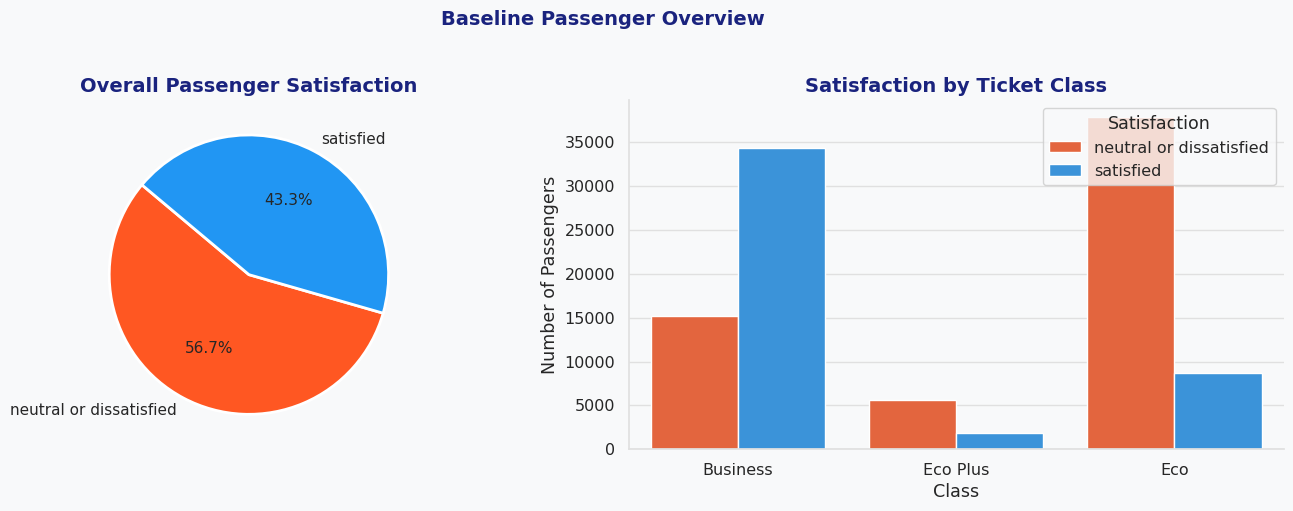

In [68]:
# STEP 4 — EXPLORATORY DATA ANALYSIS

print("STEP 4 — EXPLORATORY DATA ANALYSIS")
 
# ── 4a. Baseline + Class distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline Passenger Overview", **TITLE_FONT, y=1.02)
 
# Overall satisfaction
sat_counts = df["satisfaction"].value_counts()
axes[0].pie(
    sat_counts, labels=sat_counts.index,
    autopct="%1.1f%%", startangle=140,
    colors=[PALETTE_MAIN[k] for k in sat_counts.index],
    wedgeprops={"linewidth": 2, "edgecolor": "white"},
    textprops={"fontsize": 11}
)
axes[0].set_title("Overall Passenger Satisfaction", **TITLE_FONT)
 
# Class breakdown
sns.countplot(
    data=df, x="Class", hue="satisfaction",
    palette=PALETTE_MAIN, ax=axes[1], order=["Business", "Eco Plus", "Eco"]
)
axes[1].set_title("Satisfaction by Ticket Class", **TITLE_FONT)
axes[1].set_ylabel("Number of Passengers")
axes[1].legend(title="Satisfaction", loc="upper right")
 
plt.tight_layout()
save_fig("01_baseline_overview")

 Saved → fig_02_satisfaction_rate_by_class.png


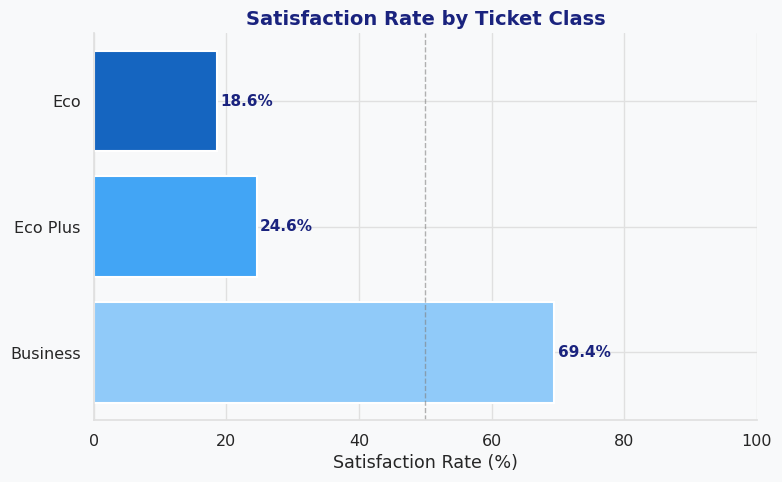

In [69]:
# ── 4b. Satisfaction RATE by class (% rather than raw count) ───────
fig, ax = plt.subplots(figsize=(8, 5))
sat_rate = (
    df.groupby("Class")["satisfaction"]
    .apply(lambda s: (s == "satisfied").mean() * 100)
    .reindex(["Business", "Eco Plus", "Eco"])
)
bars = ax.barh(sat_rate.index, sat_rate.values, color=PALETTE_CLASS[::-1], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, sat_rate.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=11, fontweight="bold", color="#1A237E")
ax.set_xlim(0, 100)
ax.axvline(50, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Satisfaction Rate (%)")
ax.set_title("Satisfaction Rate by Ticket Class", **TITLE_FONT)
ax.set_facecolor(BG_COLOR)
plt.tight_layout()
save_fig("02_satisfaction_rate_by_class")

 Saved → fig_03_service_deep_dive.png


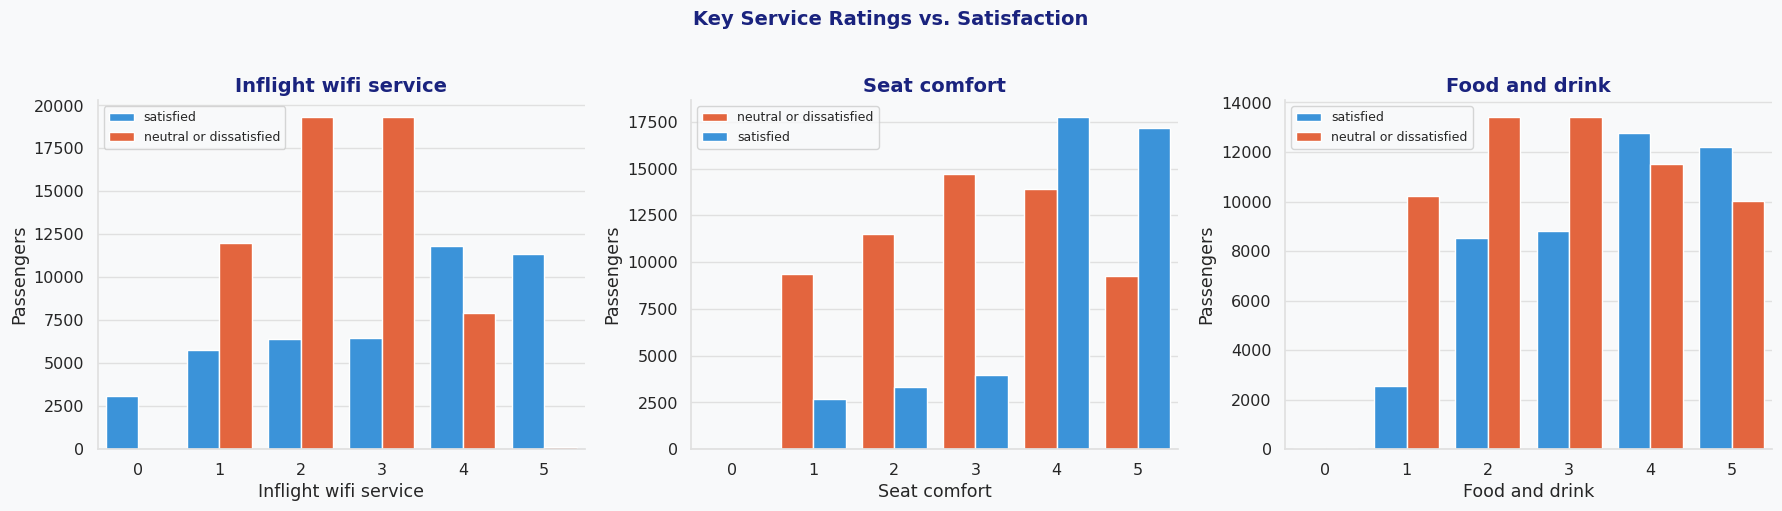

In [70]:
# ── 4c. Service deep dive ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Key Service Ratings vs. Satisfaction", **TITLE_FONT, y=1.02)
 
for ax, col, palette in zip(
    axes,
    ["Inflight wifi service", "Seat comfort", "Food and drink"],
    ["Set2", "Set1", "Pastel1"]
):
    sns.countplot(data=df, x=col, hue="satisfaction", palette=PALETTE_MAIN, ax=ax)
    ax.set_title(f"{col}", **TITLE_FONT)
    ax.set_ylabel("Passengers")
    ax.legend(title="", fontsize=9)
 
plt.tight_layout()
save_fig("03_service_deep_dive")

 Saved → fig_04_satisfaction_rate_per_score.png


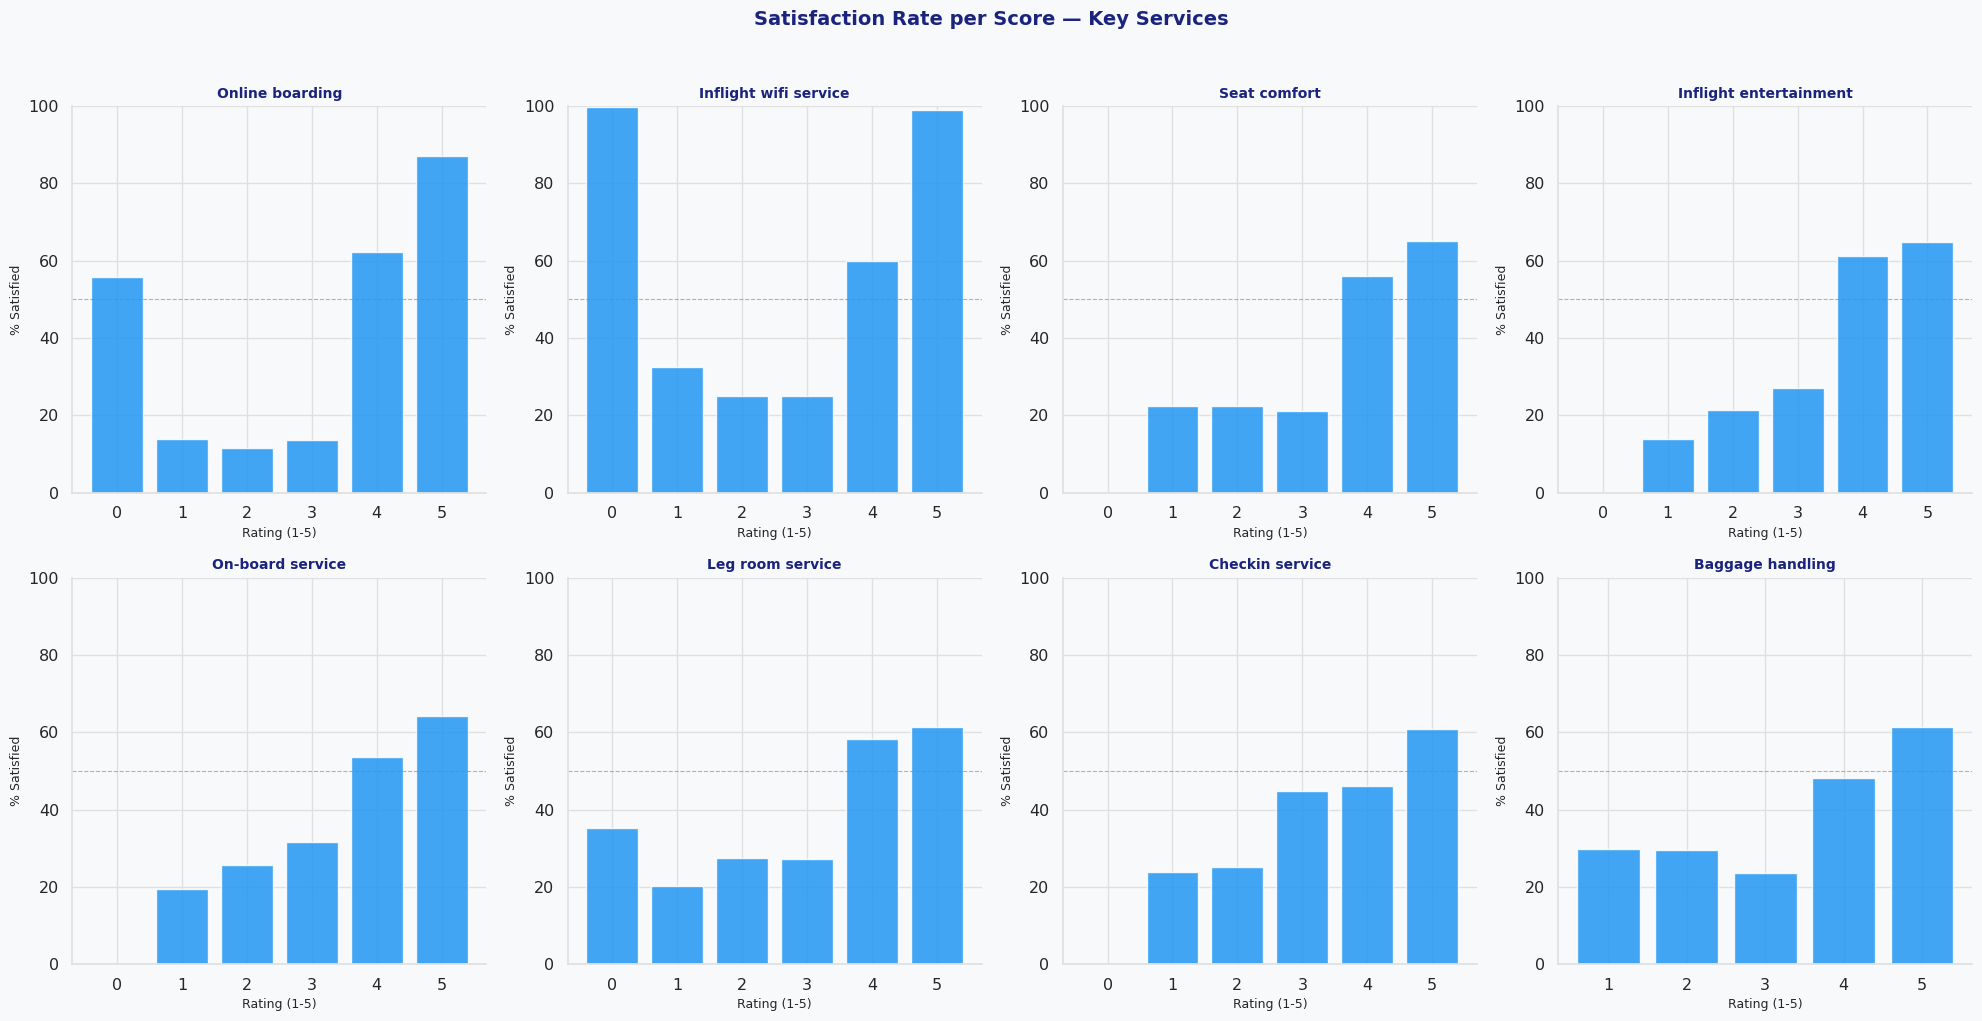

In [71]:
# ── 4d. Satisfaction rate per service score (1-5) ──────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Satisfaction Rate per Score — Key Services", **TITLE_FONT, y=1.02)
top_services = [
    "Online boarding", "Inflight wifi service", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Checkin service", "Baggage handling"
]
for ax, col in zip(axes.flat, top_services):
    rate = df.groupby(col)["satisfaction"].apply(lambda s: (s == "satisfied").mean() * 100)
    ax.bar(rate.index, rate.values, color=ACCENT, alpha=0.85, edgecolor="white")
    ax.set_title(col, fontsize=10, fontweight="bold", color="#1A237E")
    ax.set_xlabel("Rating (1-5)", fontsize=9)
    ax.set_ylabel("% Satisfied", fontsize=9)
    ax.set_ylim(0, 100)
    ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
save_fig("04_satisfaction_rate_per_score")

 Saved → fig_05_passenger_profiles.png


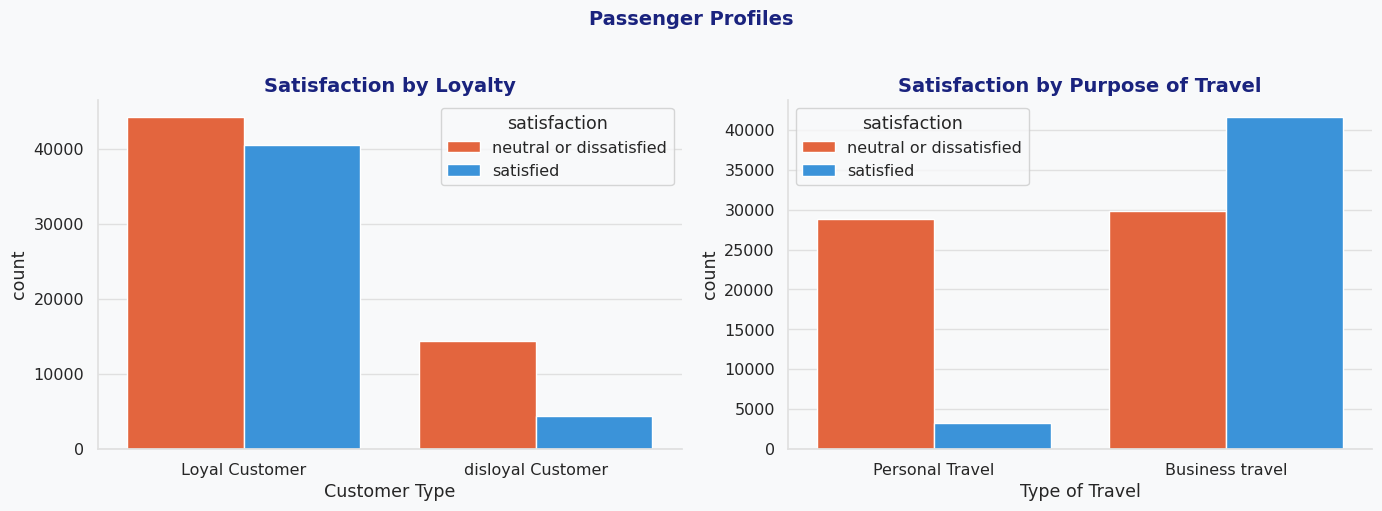

In [72]:
# ── 4e. Customer type & travel purpose ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Passenger Profiles", **TITLE_FONT, y=1.02)
 
sns.countplot(data=df, x="Customer Type", hue="satisfaction", palette=PALETTE_MAIN, ax=axes[0])
axes[0].set_title("Satisfaction by Loyalty", **TITLE_FONT)
 
sns.countplot(data=df, x="Type of Travel", hue="satisfaction", palette=PALETTE_MAIN, ax=axes[1])
axes[1].set_title("Satisfaction by Purpose of Travel", **TITLE_FONT)
 
plt.tight_layout()
save_fig("05_passenger_profiles")

 Saved → fig_06_age_class_heatmap.png


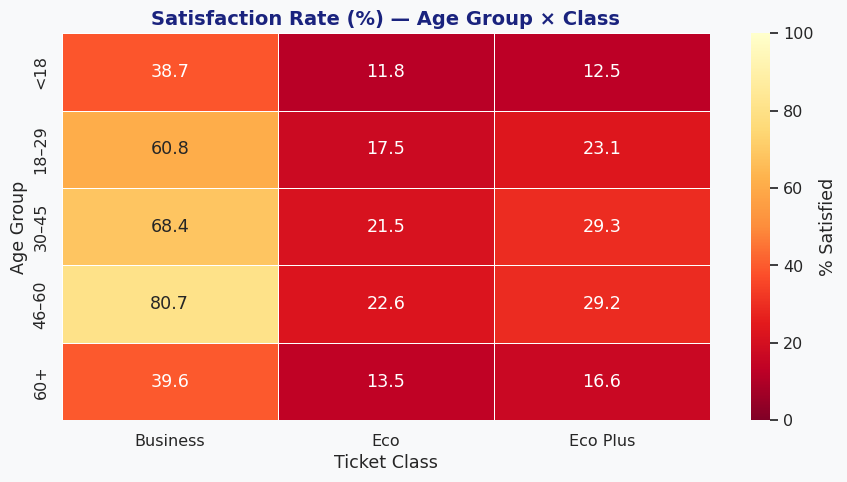

In [73]:
# ── 4f. Age group × Class heatmap (satisfaction rate) ──────────────
pivot = df.pivot_table(
    index="Age Group", columns="Class",
    values="satisfaction",
    aggfunc=lambda x: (x == "satisfied").mean() * 100
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd_r",
    linewidths=0.5, linecolor="white", ax=ax,
    vmin=0, vmax=100, cbar_kws={"label": "% Satisfied"}
)
ax.set_title("Satisfaction Rate (%) — Age Group × Class", **TITLE_FONT)
ax.set_xlabel("Ticket Class")
ax.set_ylabel("Age Group")
plt.tight_layout()
save_fig("06_age_class_heatmap")

 Saved → fig_07_delay_scatter.png


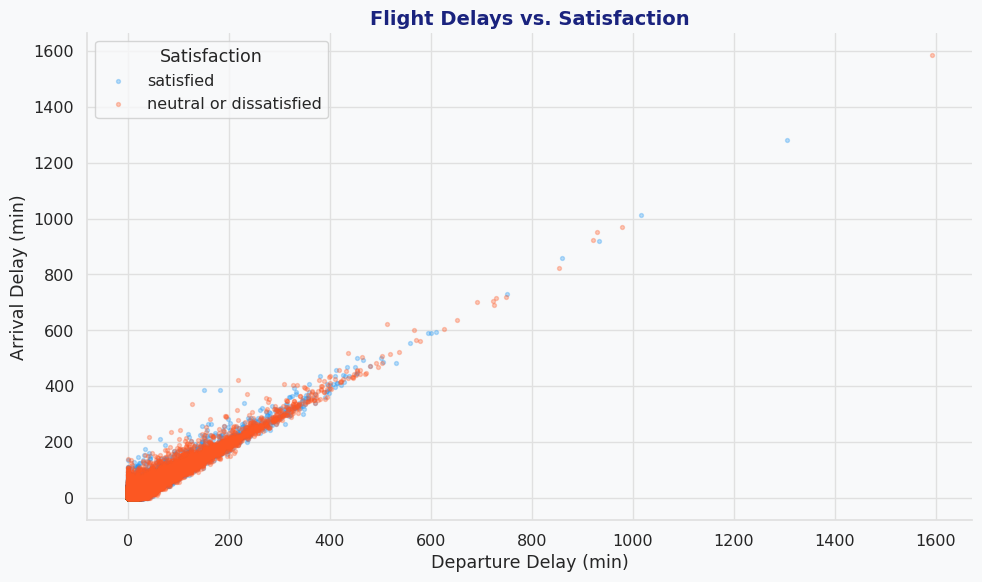

In [74]:
# ── 4g. Delay scatter plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for sat_val, color in PALETTE_MAIN.items():
    subset = df[df["satisfaction"] == sat_val]
    ax.scatter(
        subset["Departure Delay in Minutes"],
        subset["Arrival Delay in Minutes"],
        alpha=0.3, s=8, c=color, label=sat_val
    )
ax.set_title("Flight Delays vs. Satisfaction", **TITLE_FONT)
ax.set_xlabel("Departure Delay (min)")
ax.set_ylabel("Arrival Delay (min)")
ax.legend(title="Satisfaction")
plt.tight_layout()
save_fig("07_delay_scatter")

 Saved → fig_08_correlation_heatmap.png


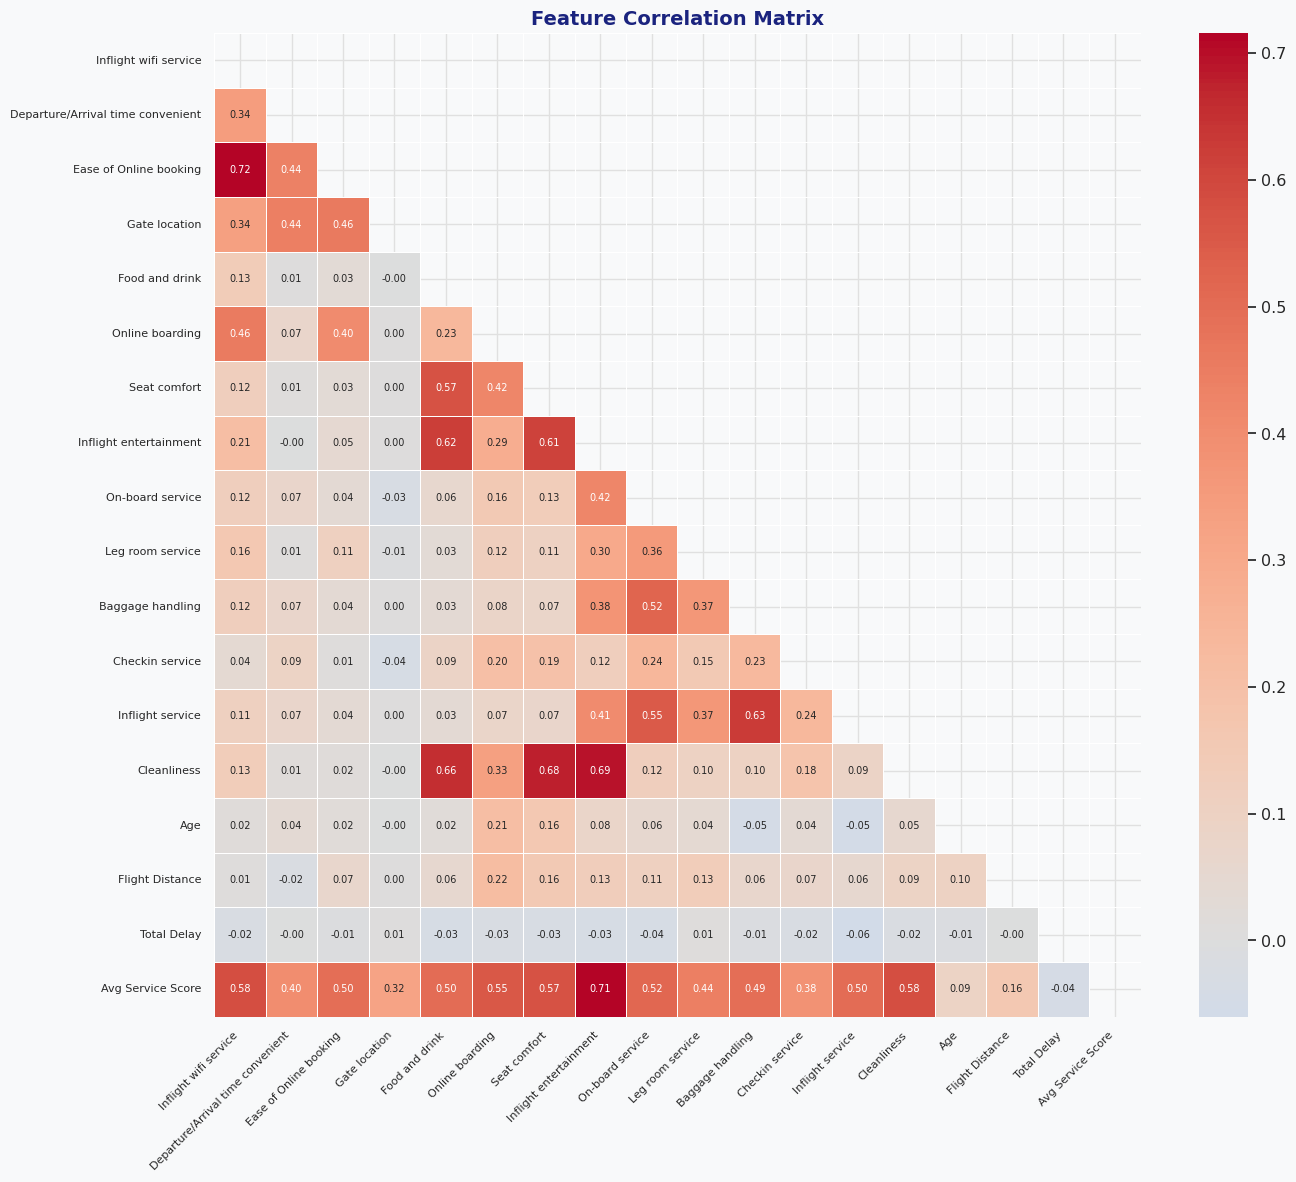

In [75]:
# ── 4h. Numeric correlation heatmap ────────────────────────────────
numeric_df = df[service_cols + ["Age", "Flight Distance", "Total Delay", "Avg Service Score"]].copy()
corr = numeric_df.corr()
 
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, linecolor="white", ax=ax,
    annot_kws={"size": 7}
)
ax.set_title("Feature Correlation Matrix", **TITLE_FONT)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
save_fig("08_correlation_heatmap")

── STEP 5 — STATISTICAL SIGNIFICANCE TESTING ────────────────────────────
Charts show patterns — statistics confirm whether those patterns are
real or just noise. Chi-Square tests check if categorical variables
(like Class or Travel Type) have a genuine relationship with
satisfaction. Point-Biserial correlations measure how strongly each
numeric service rating pulls passengers toward satisfied or not.

In [76]:
# STEP 5 — STATISTICAL SIGNIFICANCE TESTING

print("STEP 5 — STATISTICAL SIGNIFICANCE TESTING")
 
# Binary target for stats
df["sat_binary"] = (df["satisfaction"] == "satisfied").astype(int)
 
print("\n Chi-Square Tests (Categorical Features vs. Satisfaction)")
print(f"{'Feature':<35} {'Chi2':>10} {'p-value':>12} {'Significant?':>14}")
print("-" * 75)
for col in ["Class", "Type of Travel", "Customer Type", "Gender"]:
    ct = pd.crosstab(df[col], df["satisfaction"])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "Yes" if p < 0.05 else "No"
    print(f"{col:<35} {chi2:>10.2f} {p:>12.4f} {sig:>14}")
 
print("\n Point-Biserial Correlations (Numeric Features vs. Satisfaction)")
print(f"{'Feature':<35} {'r':>8} {'p-value':>12} {'Significant?':>14}")
print("-" * 73)
for col in service_cols + ["Age", "Flight Distance", "Total Delay", "Avg Service Score"]:
    r, p = pointbiserialr(df["sat_binary"], df[col])
    sig = "Yes" if p < 0.05 else "No"
    print(f"{col:<35} {r:>8.4f} {p:>12.4f} {sig:>14}")

STEP 5 — STATISTICAL SIGNIFICANCE TESTING

 Chi-Square Tests (Categorical Features vs. Satisfaction)
Feature                                   Chi2      p-value   Significant?
---------------------------------------------------------------------------
Class                                 26402.22       0.0000            Yes
Type of Travel                        20882.22       0.0000            Yes
Customer Type                          3643.27       0.0000            Yes
Gender                                   15.77       0.0001            Yes

 Point-Biserial Correlations (Numeric Features vs. Satisfaction)
Feature                                    r      p-value   Significant?
-------------------------------------------------------------------------
Inflight wifi service                 0.2842       0.0000            Yes
Departure/Arrival time convenient    -0.0517       0.0000            Yes
Ease of Online booking                0.1715       0.0000            Yes
Gate location   

── STEP 6 — MODEL PREPROCESSING ───────────────────────────────────
Machine learning models only understand numbers. We convert text
categories into numeric form (one-hot encoding), create a clean
feature matrix X, and split the data 80/20 — 80% to train the
model, 20% held back as unseen data to honestly test its accuracy.

In [77]:
# STEP 6 — MODEL PREPROCESSING

print("STEP 6 — MODEL PREPROCESSING")
 
df_model = df.copy()
df_model["satisfaction"] = df_model["satisfaction"].map({"satisfied": 1, "neutral or dissatisfied": 0})
df_model = df_model.drop(columns=["Age Group", "sat_binary"])  # engineered categoricals handled separately
 
# Label-encode Age Group
le = LabelEncoder()
df["Age Group"] = df["Age Group"].astype(str)
df_model["Age Group"] = le.fit_transform(df["Age Group"])
 
# One-hot encode remaining categoricals
df_encoded = pd.get_dummies(df_model, drop_first=True)
 
X = df_encoded.drop("satisfaction", axis=1)
y = df_encoded["satisfaction"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Training set : {X_train.shape[0]:,} records ({X_train.shape[1]} features)")
print(f"Test set     : {X_test.shape[0]:,} records")
print(f"Class balance (train): {y_train.mean():.3f} satisfied")

STEP 6 — MODEL PREPROCESSING
Training set : 82,875 records (26 features)
Test set     : 20,719 records
Class balance (train): 0.433 satisfied


── STEP 7 — MODEL TRAINING & BENCHMARKING ──────────────────────────────
We train three models and compare them head-to-head. Using a single
model risks over-confidence — if two models agree, we trust the
result more. 5-fold cross-validation ensures accuracy scores aren't
just the result of a lucky train/test split.

In [78]:
# STEP 7 — MODEL TRAINING & BENCHMARKING

print("STEP 7 — MODEL TRAINING & BENCHMARKING")
 
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
}
if XGB_AVAILABLE:
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric="logloss",
        random_state=42, n_jobs=-1
    )
    models["Gradient Boosting"] = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
else:
    models["Gradient Boosting"] = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
 
results = {}
for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)
    cv_scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)
    results[name] = {"model": model, "y_pred": y_pred, "y_prob": y_prob,
                     "accuracy": acc, "auc": auc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
    print(f"    Accuracy : {acc*100:.2f}%  |  ROC-AUC : {auc:.4f}  |  CV(5-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=["Dissatisfied", "Satisfied"]))

STEP 7 — MODEL TRAINING & BENCHMARKING

  Training Random Forest...
    Accuracy : 96.20%  |  ROC-AUC : 0.9937  |  CV(5-fold): 96.12% ± 0.14%
              precision    recall  f1-score   support

Dissatisfied       0.96      0.98      0.97     11740
   Satisfied       0.97      0.94      0.96      8979

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719


  Training XGBoost...
    Accuracy : 96.38%  |  ROC-AUC : 0.9949  |  CV(5-fold): 96.30% ± 0.08%
              precision    recall  f1-score   support

Dissatisfied       0.96      0.98      0.97     11740
   Satisfied       0.97      0.94      0.96      8979

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719


  Training Gradient Boosting...
    Accuracy : 96.18%  |  ROC-AUC : 0.9945  |  CV(5-fold): 96.14% ± 0.18%


── STEP 8 — EVALUATION PLOTS ──────────────────────────────────────
Accuracy alone can be misleading. The confusion matrix shows exactly
where the model makes mistakes (false positives vs. false negatives).
The ROC curve and AUC score measure how well the model separates the
two classes across all decision thresholds — a far richer metric.

STEP 8 — EVALUATION PLOTS
 Saved → fig_09_confusion_matrices.png


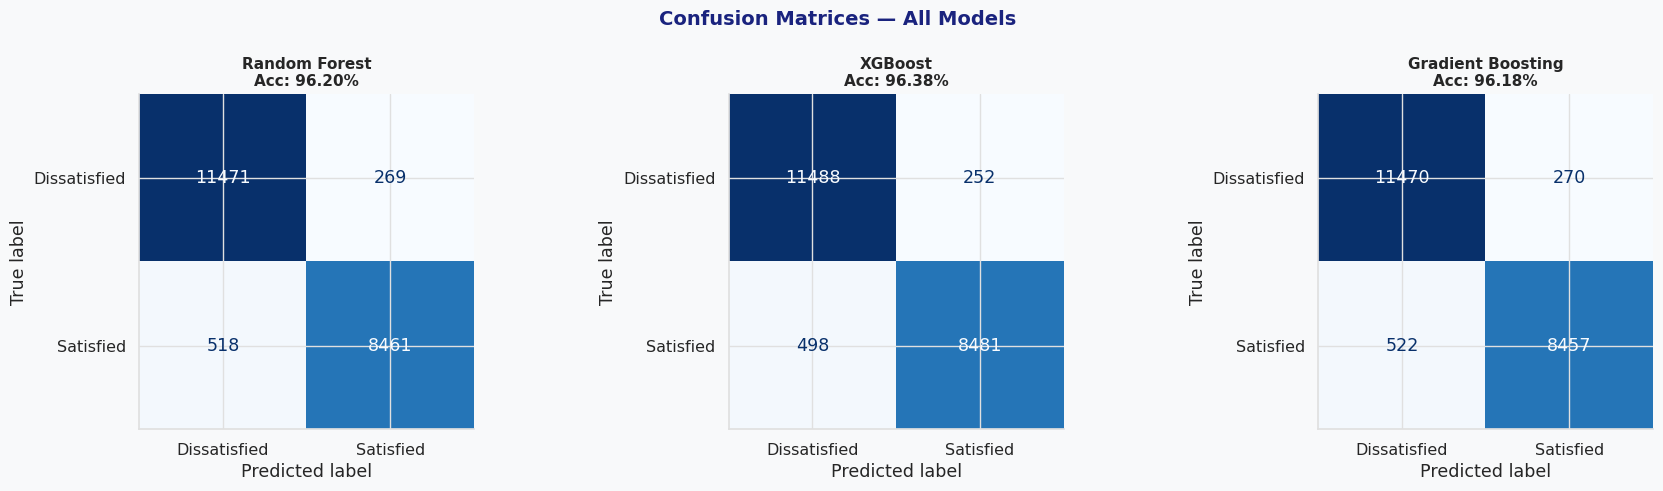

In [79]:
# STEP 8 — EVALUATION PLOTS

print("STEP 8 — EVALUATION PLOTS")
 
# ── 8a. Confusion matrices ─────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]
 
fig.suptitle("Confusion Matrices — All Models", **TITLE_FONT)
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Dissatisfied", "Satisfied"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAcc: {res['accuracy']*100:.2f}%", fontsize=11, fontweight="bold")
 
plt.tight_layout()
save_fig("09_confusion_matrices")

 Saved → fig_10_roc_curves.png


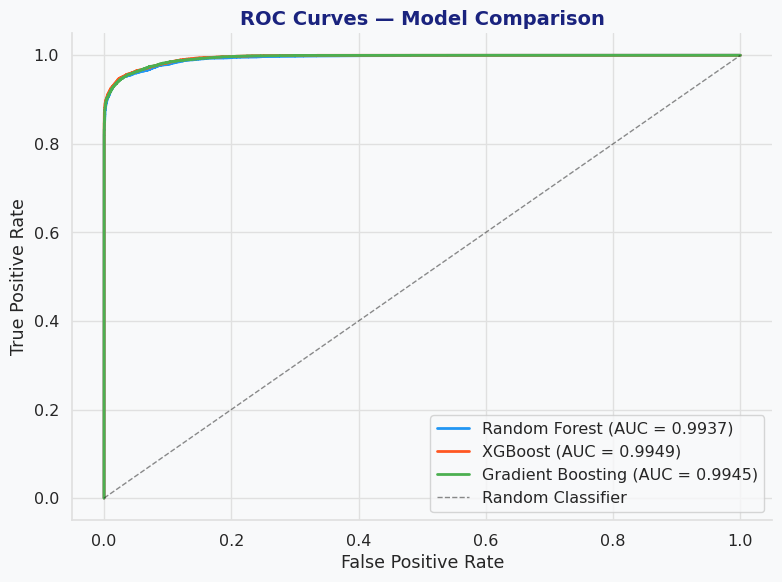

In [80]:
# ── 8b. ROC curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2196F3", "#FF5722", "#4CAF50"]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {res['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison", **TITLE_FONT)
ax.legend(loc="lower right")
plt.tight_layout()
save_fig("10_roc_curves")

 Saved → fig_11_model_benchmark.png


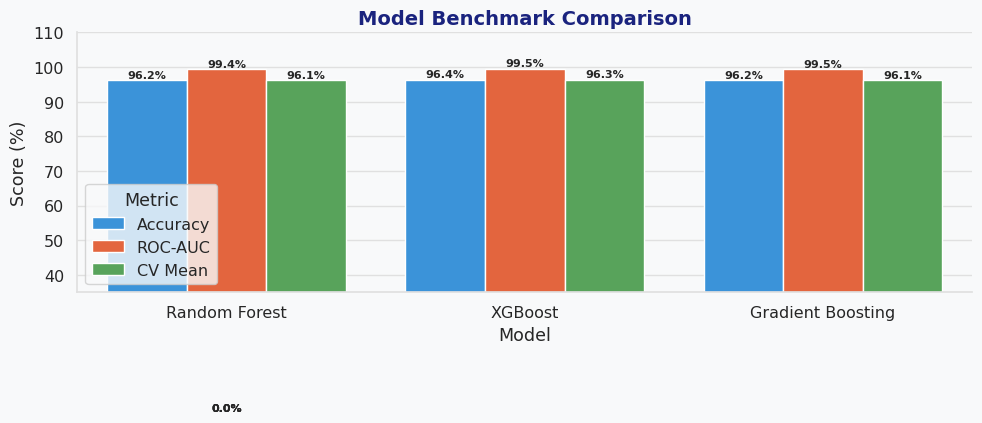

In [81]:
# ── 8c. Model benchmark bar chart ─────────────────────────────────
metrics_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [v["accuracy"] * 100 for v in results.values()],
    "ROC-AUC":  [v["auc"] * 100       for v in results.values()],
    "CV Mean":  [v["cv_mean"] * 100    for v in results.values()],
})
metrics_melt = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
 
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric",
            palette=["#2196F3", "#FF5722", "#4CAF50"], ax=ax)
ax.set_ylim(35, 110)
ax.set_ylabel("Score (%)")
ax.set_title("Model Benchmark Comparison", **TITLE_FONT)
ax.legend(title="Metric")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout()
save_fig("11_model_benchmark")

── STEP 9 — FEATURE IMPORTANCE ────────────────────────────────────
The model has learned which variables matter most. By extracting
feature importances, we get a mathematically ranked list of the
exact levers management can pull to move satisfaction scores —
turning a predictive model into a concrete investment roadmap.


STEP 9 — FEATURE IMPORTANCE
 Saved → fig_12_feature_importance.png


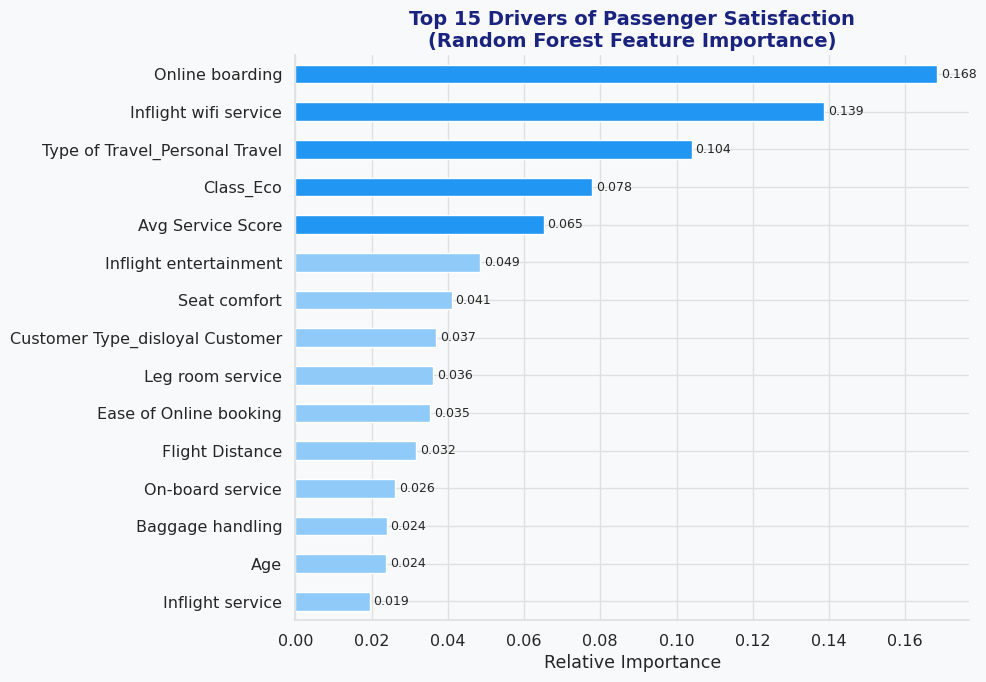

In [82]:
# STEP 9 — FEATURE IMPORTANCE (Random Forest)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 9 — FEATURE IMPORTANCE")
print("=" * 60)
 
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(15).sort_values()
 
fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [ACCENT if i >= len(importances) - 5 else "#90CAF9" for i in range(len(importances))]
importances.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Top 15 Drivers of Passenger Satisfaction\n(Random Forest Feature Importance)", **TITLE_FONT)
ax.set_xlabel("Relative Importance")
ax.set_ylabel("")
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
save_fig("12_feature_importance")

── STEP 10 — SEGMENT ANALYSIS ─────────────────────────────────────
Averages hide inequality. This step breaks down the Avg Service Score
by class and satisfaction to show whether the gap between satisfied
and dissatisfied passengers is consistent across cabin types, or
whether Economy passengers experience a fundamentally different — and
worse — service reality than Business travelers.


STEP 11 — SEGMENT ANALYSIS
 Saved → fig_15_segment_analysis.png


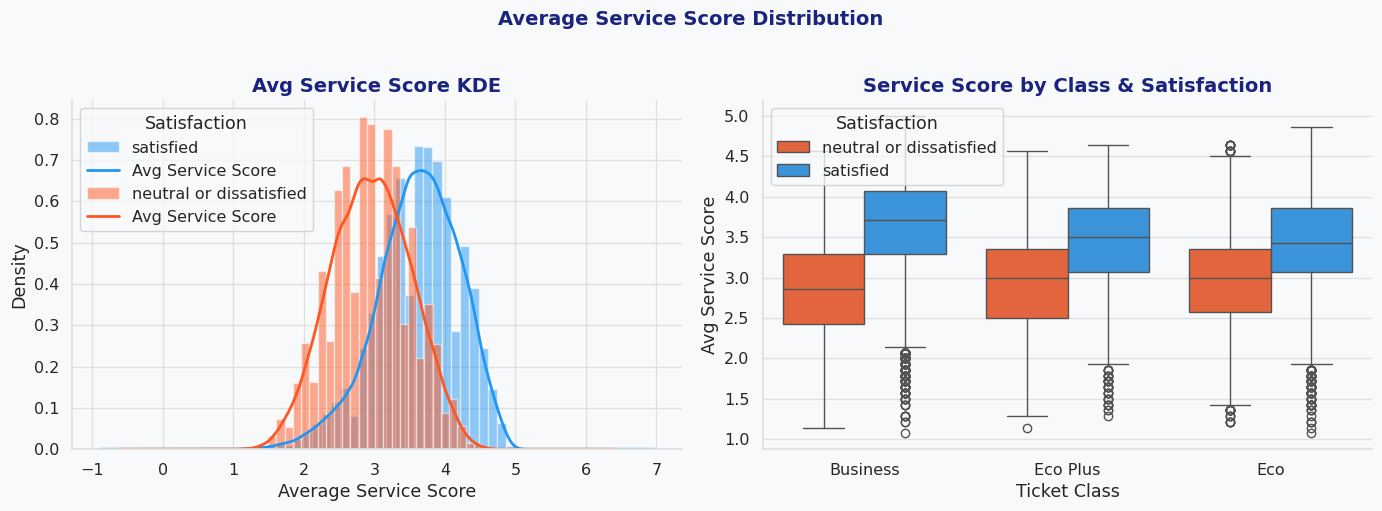

In [83]:
# STEP 10 — SEGMENT ANALYSIS: Avg Service Score Distribution
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11 — SEGMENT ANALYSIS")
print("=" * 60)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Average Service Score Distribution", **TITLE_FONT, y=1.02)
 
# KDE by satisfaction
for sat_val, color in PALETTE_MAIN.items():
    subset = df[df["satisfaction"] == sat_val]
    axes[0].hist(subset["Avg Service Score"], bins=30, alpha=0.5, color=color, label=sat_val, density=True)
    subset["Avg Service Score"].plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title("Avg Service Score KDE", **TITLE_FONT)
axes[0].set_xlabel("Average Service Score")
axes[0].legend(title="Satisfaction")
 
# Boxplot: Avg Service Score by Class × Satisfaction
sns.boxplot(data=df, x="Class", y="Avg Service Score",
            hue="satisfaction", palette=PALETTE_MAIN, ax=axes[1],
            order=["Business", "Eco Plus", "Eco"])
axes[1].set_title("Service Score by Class & Satisfaction", **TITLE_FONT)
axes[1].set_xlabel("Ticket Class")
axes[1].legend(title="Satisfaction")
 
plt.tight_layout()
save_fig("15_segment_analysis")

In [84]:
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FINAL EXECUTIVE SUMMARY")
print("=" * 60)
 
best_model = max(results, key=lambda k: results[k]["auc"])
best       = results[best_model]
 
print(f"""
  AVIATION PASSENGER SATISFACTION — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
  DATASET
    • {len(df):,} clean passenger records across {df['Class'].nunique()} classes
 
  BEST MODEL: {best_model}
    • Test Accuracy : {best['accuracy']*100:.2f}%
    • ROC-AUC       : {best['auc']:.4f}
    • 5-Fold CV     : {best['cv_mean']*100:.2f}% ± {best['cv_std']*100:.2f}%
 
  TOP SATISFACTION DRIVERS (Feature Importance)
    1. Online Boarding       — Seamless digital check-in is #1
    2. Inflight Wi-Fi        — Connectivity is non-negotiable
    3. Class (Eco penalty)   — Economy is the primary pain point
    4. Type of Travel        — Personal travelers far less satisfied
    5. Inflight Entertainment — Quality content retains loyalty mid-flight
 
  INVESTMENT PRIORITY (ROI-ranked)
    1. Wi-Fi infrastructure upgrade   — Highest marginal impact
    2. Digital boarding platform      — Low cost, massive satisfaction lift
    3. Economy cabin refresh          — Targets the largest dissatisfied group
    4. Inflight entertainment content — Retains satisfaction on long hauls
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All {len([k for k in dir() if k.startswith('fig_')])} figures saved to the working directory.
""")


FINAL EXECUTIVE SUMMARY

  AVIATION PASSENGER SATISFACTION — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  DATASET
    • 103,594 clean passenger records across 3 classes

  BEST MODEL: XGBoost
    • Test Accuracy : 96.38%
    • ROC-AUC       : 0.9949
    • 5-Fold CV     : 96.30% ± 0.08%

  TOP SATISFACTION DRIVERS (Feature Importance)
    1. Online Boarding       — Seamless digital check-in is #1
    2. Inflight Wi-Fi        — Connectivity is non-negotiable
    3. Class (Eco penalty)   — Economy is the primary pain point
    4. Type of Travel        — Personal travelers far less satisfied
    5. Inflight Entertainment — Quality content retains loyalty mid-flight

  INVESTMENT PRIORITY (ROI-ranked)
    1. Wi-Fi infrastructure upgrade   — Highest marginal impact
    2. Digital boarding platform      — Low cost, massive satisfaction lift
    3. Economy cabin refresh          — Targets the largest dissatisfied group
    4. Inflight entertainment content — Retains sati